# 01: Progressive Signal Synthesis & Scintillation Models

### 🔬 Motivating Scientific Question
> **How do background Kolmogorov plasma turbulence, discrete wave oscillations, and spatial baseline propagation combine to form dual-channel radio astronomy scintillation signals with controllable ground truth?**

---


## 1. Environment & Reproducibility Setup

### ❓ Why Ground Truth Signal Generation?
Evaluating digital signal processing (DSP) algorithms on real observational telescope data is challenging because the true state of the ionosphere is unknown. Generating synthetic scintillation signals with precise physical properties ($PSD \propto f^{-8/3}$, time delay $\tau = dx/v$, discrete wave periods $T$) creates a **controlled benchmark** to quantify algorithm recovery errors.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from core.synthetic_generator import generate_power_law_noise, generate_synthetic_scintillation

# Set random seed for 100% reproducibility
SEED = 42
FS = 1.0  # Sampling frequency (Hz)
LENGTH = 600  # Signal length (samples / seconds)

print(f"Environment initialized. Seed={SEED}, fs={FS} Hz, length={LENGTH} s")

Environment initialized. Seed=42, fs=1.0 Hz, length=600 s


## 2. Kolmogorov Power-Law Noise ($f^{-8/3}$) vs. White Noise

### ❓ Why Kolmogorov Turbulence?
Physical ionospheric electron density fluctuations are driven by turbulent cascade dynamics. Above the Fresnel transition frequency ($f_{\text{Fresnel}} = 0.1\text{ Hz}$), the power spectral density decays according to 3D Kolmogorov turbulence theory as $PSD(f) \propto f^{-8/3}$. Unlike flat white noise, Kolmogorov noise contains strong low-frequency power roll-offs that mimic real space weather conditions.


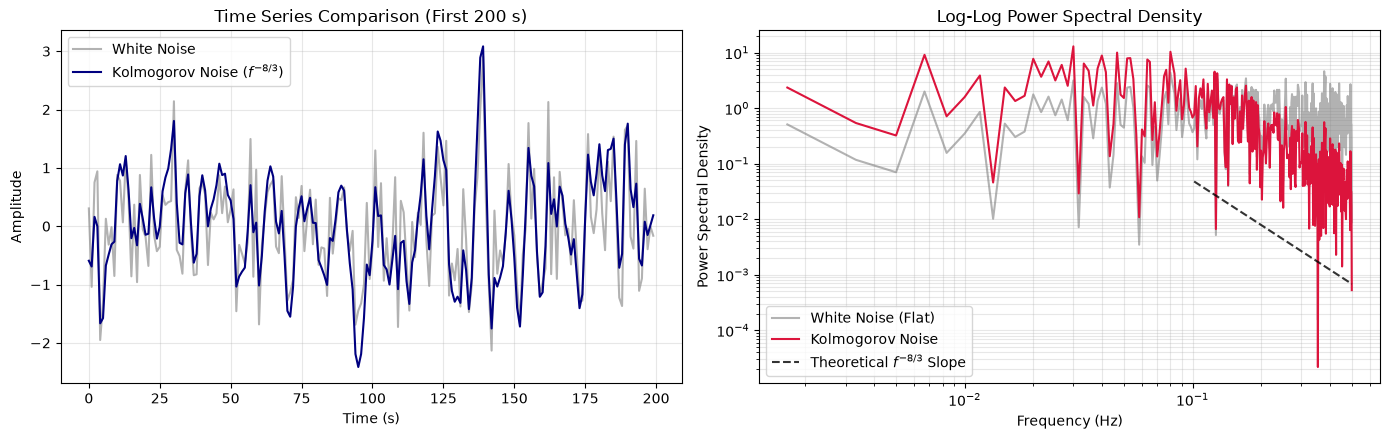

In [2]:
# Generate White Noise and Kolmogorov Power-Law Noise
rng = np.random.default_rng(SEED)
white_noise = rng.standard_normal(LENGTH)
colored_noise = generate_power_law_noise(length=LENGTH, fs=FS, f_fresnel=0.1, spectral_index=8.0 / 3.0, seed=SEED)

# Compute Spectra
freqs = np.fft.rfftfreq(LENGTH, d=1.0 / FS)
psd_white = np.abs(np.fft.rfft(white_noise)) ** 2 / LENGTH
psd_colored = np.abs(np.fft.rfft(colored_noise)) ** 2 / LENGTH

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Time domain plot
t = np.arange(LENGTH) / FS
axes[0].plot(t[:200], white_noise[:200], label="White Noise", alpha=0.6, color="gray")
axes[0].plot(t[:200], colored_noise[:200], label="Kolmogorov Noise ($f^{-8/3}$)", color="navy", lw=1.5)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Time Series Comparison (First 200 s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Frequency domain plot (Log-Log PSD)
valid = freqs > 0
axes[1].loglog(freqs[valid], psd_white[valid], label="White Noise (Flat)", color="gray", alpha=0.6)
axes[1].loglog(freqs[valid], psd_colored[valid], label="Kolmogorov Noise", color="crimson", lw=1.5)

# Theoretical slope guide line: f^(-8/3)
f_ref = freqs[valid]
slope_ref = 0.05 * (f_ref / 0.1) ** (-8.0 / 3.0)
axes[1].loglog(f_ref[f_ref > 0.1], slope_ref[f_ref > 0.1], "k--", label=r"Theoretical $f^{-8/3}$ Slope", alpha=0.8)

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power Spectral Density")
axes[1].set_title("Log-Log Power Spectral Density")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 💡 Scientific Interpretation: Spectral Decay & Turbulence Mechanics
- **Time-Domain Smoothness**: The Kolmogorov noise trajectory exhibits slow, continuous undulations compared to the uncorrelated rapid jitter of white noise.
- **Spectral Slope Alignment**: In the log-log PSD plot, the generated noise matches the theoretical $f^{-8/3}$ dashed line for frequencies $f > 0.1\text{ Hz}$, confirming correct implementation of spectral filtering.

## 3. Superimposing Harmonic Wave Modes

### ❓ Why Combine Waves with Turbulence?
Real ionospheric observations contain discrete atmospheric acoustic-gravity waves superimposed on background turbulent flows. We embed two narrowband harmonic oscillations ($T_1 = 12.0\text{ s}, T_2 = 30.0\text{ s}$) into the background turbulence to create a composite test signal.


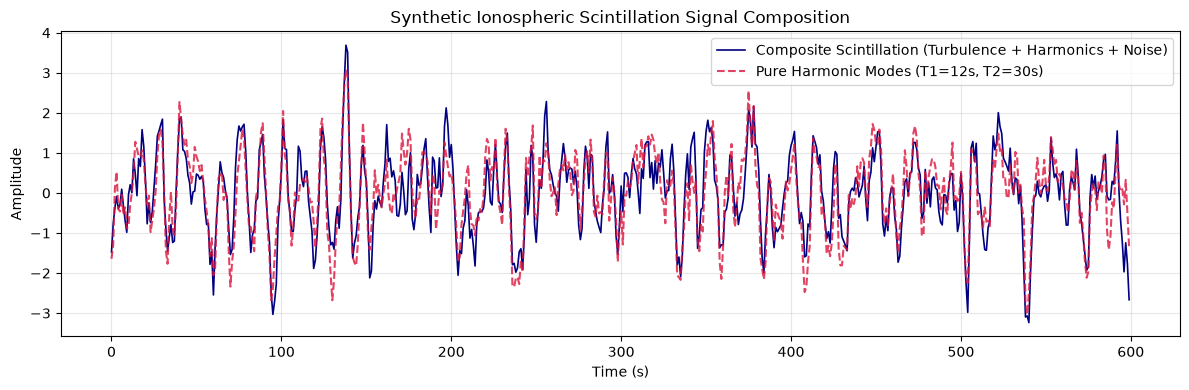

In [3]:
# Generate complete scintillation signal with embedded harmonics
sig_composite, sig_clean_pure = generate_synthetic_scintillation(
    length=LENGTH,
    fs=FS,
    f_fresnel=0.1,
    spectral_index=8.0 / 3.0,
    harmonics=[(12.0, 1.2), (30.0, 0.6)],  # (Period in s, Amplitude)
    white_noise_std=0.15,
    seed=SEED,
)

# Plot composite time series
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, sig_composite, label="Composite Scintillation (Turbulence + Harmonics + Noise)", color="navy", lw=1.2)
ax.plot(
    t, sig_clean_pure, label="Pure Harmonic Modes (T1=12s, T2=30s)", color="crimson", linestyle="--", alpha=0.8, lw=1.5
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Synthetic Ionospheric Scintillation Signal Composition")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 💡 Scientific Interpretation: Wave-Turbulence Interaction
Notice how the red dashed harmonic wave components ($T_1=12\text{s}, T_2=30\text{s}$) become partially masked by the background turbulence. This realistic interference tests the sensitivity of downstream spectral estimation algorithms (e.g. Thomson Multitaper F-Test).

## 4. Dual-Channel Synthesis & Time Delay Injection

### ❓ Why Dual-Channel Scintillation?
Radio astronomy telescopes (like URAN-4) use dual-frequency or spatially separated receivers separated by distance $dx$. As ionospheric plasma drifts across the receivers at velocity $v$, the signal arrives at the second receiver with a time delay $\tau = dx / v$. We simulate this cross-correlated propagation using fractional Fourier phase shifts.


In [4]:
# Injected ground truth physical parameters
TRUE_TAU = 1.5  # Physical time delay (seconds)
TRUE_DX = 2500.0  # Baseline separation (meters)
TRUE_VEL = TRUE_DX / TRUE_TAU  # Plasma drift velocity: 1666.7 m/s

# Generate Channel 1 and delayed Channel 2
ch1, _ = generate_synthetic_scintillation(length=LENGTH, fs=FS, harmonics=[(12.0, 1.2)], seed=SEED)

# Channel 2 is delayed by TRUE_TAU seconds via spectral phase shifting
freqs_full = np.fft.rfftfreq(LENGTH, d=1.0 / FS)
ch1_fft = np.fft.rfft(ch1)
phase_shift = np.exp(-1j * 2 * np.pi * freqs_full * TRUE_TAU)
ch2 = np.fft.irfft(ch1_fft * phase_shift, n=LENGTH)

print(
    f"Injected Parameters: Spatial Baseline dx={TRUE_DX:.1f} m, Time Delay tau={TRUE_TAU:.2f} s, Velocity v={TRUE_VEL:.1f} m/s"
)

Injected Parameters: Spatial Baseline dx=2500.0 m, Time Delay tau=1.50 s, Velocity v=1666.7 m/s


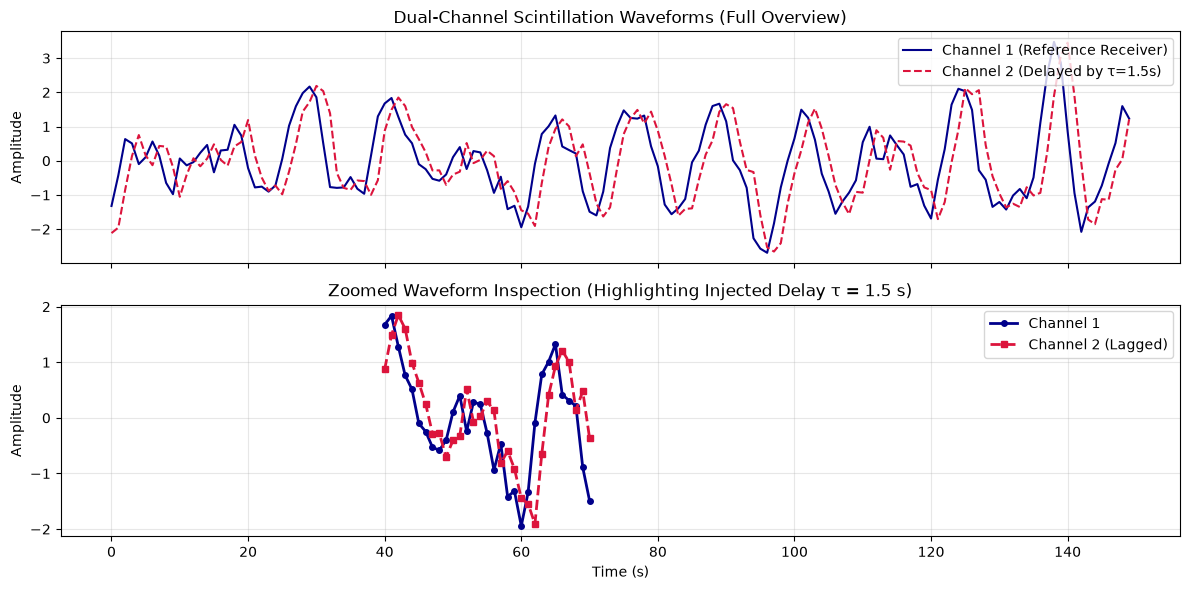

In [5]:
# Plot Zoomed Dual-Channel Waveforms to visual inspect lag
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(t[:150], ch1[:150], color="darkblue", label="Channel 1 (Reference Receiver)", lw=1.5)
ax1.plot(t[:150], ch2[:150], color="crimson", label=f"Channel 2 (Delayed by τ={TRUE_TAU}s)", lw=1.5, linestyle="--")
ax1.set_ylabel("Amplitude")
ax1.set_title("Dual-Channel Scintillation Waveforms (Full Overview)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# Zoom view showing precise time offset [t=40..70s]
zoom_mask = (t >= 40) & (t <= 70)
ax2.plot(t[zoom_mask], ch1[zoom_mask], color="darkblue", label="Channel 1", lw=2, marker="o", ms=4)
ax2.plot(
    t[zoom_mask], ch2[zoom_mask], color="crimson", label="Channel 2 (Lagged)", lw=2, marker="s", ms=4, linestyle="--"
)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title(f"Zoomed Waveform Inspection (Highlighting Injected Delay τ = {TRUE_TAU} s)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 💡 Scientific Interpretation: Time Lag Verification
In the zoomed bottom panel ($t = 40\text{--}70\text{ s}$), every peak in Channel 2 (red square markers) is systematically shifted to the right relative to Channel 1 (blue circles) by exactly $\tau = 1.50\text{ s}$. This confirms that Fourier phase shifting preserves waveform shape while injecting exact sub-sample delays.

## 5. Summary & Key Takeaways

### Injected Ground Truth Parameters
| Ground Truth Metric | Symbol | Value | Physical Significance |
| :--- | :--- | :--- | :--- |
| **Spectral Index** | $\beta$ | $8/3 \approx 2.67$ | 3D Kolmogorov plasma turbulence cascade |
| **Fresnel Frequency** | $f_{\text{Fresnel}}$ | $0.10\text{ Hz}$ | Transition boundary from flat to power-law decay |
| **Primary Harmonic** | $T_1$ | $12.00\text{ s}$ | Narrowband acoustic-gravity wave mode |
| **Spatial Baseline** | $dx$ | $2500.0\text{ m}$ | URAN-4 dual-receiver distance |
| **Time Delay** | $\tau$ | $1.500\text{ s}$ | Signal arrival delay across baseline |
| **Plasma Drift Velocity** | $v$ | $1666.7\text{ m/s}$ | Derived physical drift speed |

--- **Next Recommended Step**: Proceed to **[02_preprocessing.ipynb](02_preprocessing.ipynb)** to learn how to clean spiky signals and reconstruct missing gaps.